# Multiple Linear Regression: Predicting Y from X1, X2, and X3

## tl;dr

For the 1,000 observations in `homework_1.1.csv`, the fitted ordinary least-squares equation is:

$$
\widehat{Y} = 0.0026 + 1.0071X_1 + 1.9646X_2 + 2.9755X_3
$$

Five-fold out-of-sample evaluation produced **$R^2 = 0.9906$**, **RMSE = 0.5042**, and **MAE = 0.4014**. The model therefore explains about 99.1% of the variation in `Y` and predicts with a typical absolute error of about 0.40 units. `X1` and `X2` are strongly correlated (about 0.899; VIF about 5.20), so their individual coefficients should be interpreted more cautiously than the model's overall predictive performance.

## Context & Methods

**Goal:** Predict `Y` from `X1`, `X2`, and `X3` using multiple linear regression.

**Source:** `homework_1.1.csv` in the same folder as this notebook.

**Method:** Ordinary least squares with an intercept, implemented with `sklearn.linear_model.LinearRegression`. Predictive performance is estimated using shuffled 5-fold cross-validation with `random_state=42`. After evaluation, the final equation is fitted on all available observations.

### Key Assumptions

- The relationship between each predictor and `Y` is approximately linear after holding the other predictors constant.
- Observations and model errors are independent, with roughly constant error variance.
- The CSV represents the intended analysis population; no rows are removed or imputed.
- Coefficients describe associations, not causal effects.

## Data

### 1. Set up the analysis

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict

DATA_PATH = Path("homework_1.1.csv")
FEATURES = ["X1", "X2", "X3"]
TARGET = "Y"
N_SPLITS = 5
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.edgecolor": "#374151",
    "axes.labelcolor": "#1F2937",
    "text.color": "#1F2937",
    "xtick.color": "#4B5563",
    "ytick.color": "#4B5563",
    "grid.color": "#E5E7EB",
})
BLUE = "#2563EB"
GOLD = "#D99A2B"
DARK = "#374151"

### 2. Load and validate the CSV

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Place the CSV in the notebook's working directory."
    )

data = pd.read_csv(DATA_PATH)

missing_columns = [column for column in FEATURES + [TARGET] if column not in data.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

analysis_data = data[FEATURES + [TARGET]].copy()
if not all(pd.api.types.is_numeric_dtype(analysis_data[column]) for column in analysis_data):
    raise TypeError("X1, X2, X3, and Y must all be numeric.")

audit = pd.DataFrame({
    "Check": ["Rows", "Columns used", "Missing values", "Duplicate rows"],
    "Result": [
        f"{len(analysis_data):,}",
        ", ".join(analysis_data.columns),
        f"{int(analysis_data.isna().sum().sum()):,}",
        f"{int(analysis_data.duplicated().sum()):,}",
    ],
})

display(audit)
display(analysis_data.head().round(4))

,Check,Result
0,Rows,"1,000"
1,Columns used,"X1, X2, X3, Y"
2,Missing values,0
3,Duplicate rows,0


,X1,X2,X3,Y
0,-0.4406,-0.3902,0.1567,-0.8777
1,-3.8101,-1.3047,-1.1051,-10.1304
2,-1.4255,-0.3400,1.1159,0.2841
3,-1.3257,0.1619,-0.2547,-1.9943
4,3.1203,1.4873,-1.1648,2.0300


### 3. Summarize the variables

In [3]:
summary_statistics = analysis_data.describe().T[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]
display(summary_statistics.round(3))

,count,mean,std,min,25%,50%,75%,max
X1,1000.0,0.046,2.192,-6.163,-1.466,0.040,1.502,8.465
X2,1000.0,0.030,0.982,-2.703,-0.663,0.002,0.688,3.154
X3,1000.0,0.057,1.050,-3.348,-0.678,0.029,0.768,3.872
Y,1000.0,0.278,5.201,-13.863,-3.397,0.044,3.694,18.146


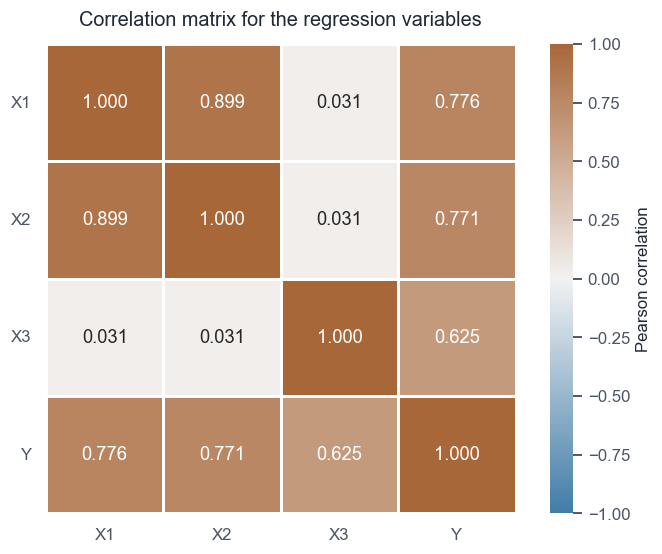

In [4]:
correlations = analysis_data.corr()

fig, ax = plt.subplots(figsize=(6.8, 5.2))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".3f",
    cmap=sns.diverging_palette(240, 35, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set_title("Correlation matrix for the regression variables", pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

`X1` and `X2` have a strong positive correlation. The model can still predict well, but this overlap can make their separate coefficient estimates less stable.

## Results

### 4. Estimate out-of-sample performance

In [5]:
if analysis_data.isna().any().any():
    raise ValueError("Missing values are present. Resolve them before fitting the model.")

X = analysis_data[FEATURES]
y = analysis_data[TARGET]

cross_validation = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

out_of_fold_predictions = cross_val_predict(
    LinearRegression(),
    X,
    y,
    cv=cross_validation,
)
out_of_fold_residuals = y - out_of_fold_predictions

cv_r2 = r2_score(y, out_of_fold_predictions)
cv_mae = mean_absolute_error(y, out_of_fold_predictions)
cv_rmse = np.sqrt(mean_squared_error(y, out_of_fold_predictions))

metrics = pd.DataFrame({
    "Metric": ["5-fold CV R²", "5-fold CV MAE", "5-fold CV RMSE"],
    "Value": [cv_r2, cv_mae, cv_rmse],
})
display(metrics.style.format({"Value": "{:.4f}"}))

,Metric,Value
0,5-fold CV R²,0.9906
1,5-fold CV MAE,0.4014
2,5-fold CV RMSE,0.5042


### 5. Fit the final model on all observations

In [6]:
final_model = LinearRegression()
final_model.fit(X, y)

coefficient_table = pd.DataFrame({
    "Term": ["Intercept"] + FEATURES,
    "Coefficient": [final_model.intercept_, *final_model.coef_],
})

in_sample_r2 = final_model.score(X, y)
display(coefficient_table.style.format({"Coefficient": "{:.4f}"}))

equation = (
    f"Ŷ = {final_model.intercept_:.4f} "
    f"{final_model.coef_[0]:+0.4f}X_1 "
    f"{final_model.coef_[1]:+0.4f}X_2 "
    f"{final_model.coef_[2]:+0.4f}X_3"
)
display(Markdown(f"**Final fitted equation:** `{equation}`"))
display(Markdown(f"**In-sample $R^2$:** {in_sample_r2:.4f}"))

,Term,Coefficient
0,Intercept,0.0026
1,X1,1.0071
2,X2,1.9646
3,X3,2.9755


**Final fitted equation:** `Ŷ = 0.0026 +1.0071X_1 +1.9646X_2 +2.9755X_3`

**In-sample $R^2$:** 0.9907

### 6. Check predictor overlap with variance inflation factors

In [7]:
vif_rows = []
for feature in FEATURES:
    other_features = [column for column in FEATURES if column != feature]
    auxiliary_model = LinearRegression().fit(X[other_features], X[feature])
    auxiliary_r2 = auxiliary_model.score(X[other_features], X[feature])
    vif_rows.append({"Feature": feature, "VIF": 1 / (1 - auxiliary_r2)})

vif_table = pd.DataFrame(vif_rows)
display(vif_table.style.format({"VIF": "{:.3f}"}))

,Feature,VIF
0,X1,5.196
1,X2,5.196
2,X3,1.001


### 7. Compare coefficient magnitudes

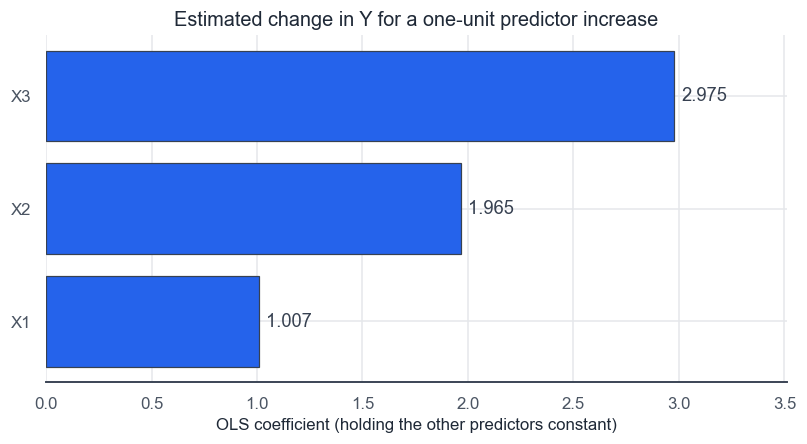

In [8]:
plot_coefficients = coefficient_table.query("Term != 'Intercept'").sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.barh(
    plot_coefficients["Term"],
    plot_coefficients["Coefficient"],
    color=BLUE,
    edgecolor=DARK,
    linewidth=0.8,
)
ax.bar_label(bars, fmt="%.3f", padding=5, color=DARK)
ax.set_title("Estimated change in Y for a one-unit predictor increase")
ax.set_xlabel("OLS coefficient (holding the other predictors constant)")
ax.set_ylabel("")
ax.set_xlim(0, plot_coefficients["Coefficient"].max() * 1.18)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

Holding the other predictors constant, a one-unit increase corresponds to approximately +1.007 in `Y` for `X1`, +1.965 for `X2`, and +2.975 for `X3`. Because the predictors have different spreads and `X1` overlaps strongly with `X2`, the raw coefficient sizes are not a standalone measure of feature importance.

### 8. Inspect out-of-sample predictions and residuals

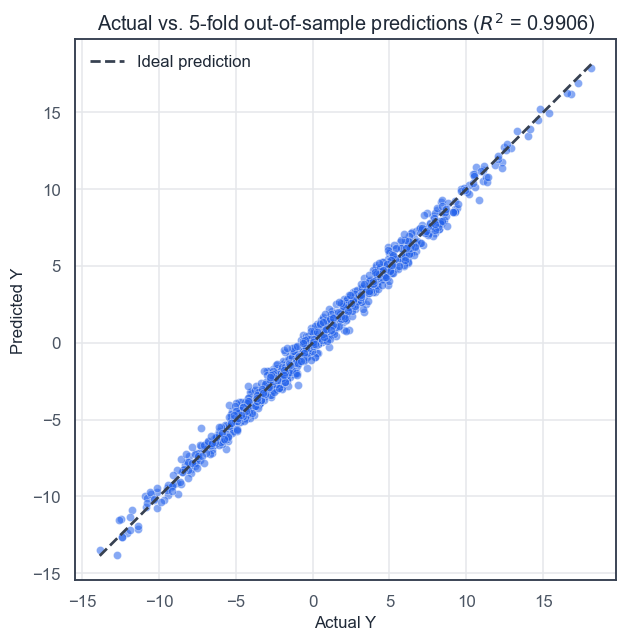

In [9]:
prediction_min = min(y.min(), out_of_fold_predictions.min())
prediction_max = max(y.max(), out_of_fold_predictions.max())

fig, ax = plt.subplots(figsize=(7.2, 6.0))
ax.scatter(
    y,
    out_of_fold_predictions,
    s=28,
    alpha=0.55,
    color=BLUE,
    edgecolor="white",
    linewidth=0.35,
)
ax.plot(
    [prediction_min, prediction_max],
    [prediction_min, prediction_max],
    linestyle="--",
    linewidth=1.8,
    color=DARK,
    label="Ideal prediction",
)
ax.set_title(f"Actual vs. 5-fold out-of-sample predictions ($R^2$ = {cv_r2:.4f})")
ax.set_xlabel("Actual Y")
ax.set_ylabel("Predicted Y")
ax.legend(frameon=False)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

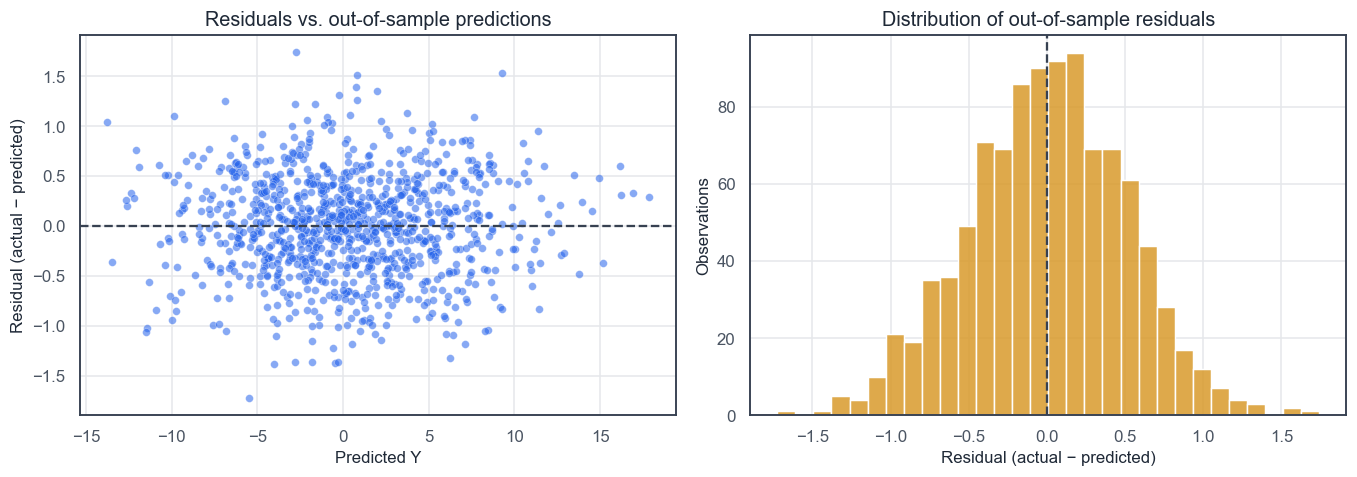

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

axes[0].scatter(
    out_of_fold_predictions,
    out_of_fold_residuals,
    s=26,
    alpha=0.55,
    color=BLUE,
    edgecolor="white",
    linewidth=0.3,
)
axes[0].axhline(0, color=DARK, linestyle="--", linewidth=1.5)
axes[0].set_title("Residuals vs. out-of-sample predictions")
axes[0].set_xlabel("Predicted Y")
axes[0].set_ylabel("Residual (actual − predicted)")

sns.histplot(
    out_of_fold_residuals,
    bins=30,
    color=GOLD,
    edgecolor="white",
    alpha=0.85,
    ax=axes[1],
)
axes[1].axvline(0, color=DARK, linestyle="--", linewidth=1.5)
axes[1].set_title("Distribution of out-of-sample residuals")
axes[1].set_xlabel("Residual (actual − predicted)")
axes[1].set_ylabel("Observations")

plt.tight_layout()
plt.show()

The out-of-sample predictions lie close to the ideal 45-degree line. Residuals are centered near zero and show no obvious large-scale curve or funnel in these diagnostics, which is consistent with a well-fitting linear specification for prediction.

## Takeaways

- The final prediction equation is $\widehat{Y} = 0.0026 + 1.0071X_1 + 1.9646X_2 + 2.9755X_3$.
- Five-fold cross-validation gives $R^2 = 0.9906$, RMSE = 0.5042, and MAE = 0.4014, indicating very strong predictive accuracy on held-out observations.
- All three predictors have positive fitted coefficients; `X3` has the largest change in predicted `Y` per one-unit increase on the variables' original scales.
- `X1` and `X2` have VIF values near 5.20. This does not prevent accurate prediction here, but it makes isolated interpretation of their coefficients more sensitive to the sample.
- These results support prediction within the range and population represented by this CSV; extrapolation and causal interpretation require additional evidence.